# Unit06_Example_04 | 批次反應系統之穩態成分分析

本 Notebook 以六成分批次可逆反應系統為例，示範如何將**動力學 ODE 系統**轉化為**穩態線性方程組**，並處理矩陣奇異性問題以使用 `scipy.linalg.solve()` 求解唯一解。

## 目標
1. 從一次反應動力學方程式推導穩態線性方程組
2. 分析動力學矩陣的奇異性（$\text{rank}(\mathbf{A}) < n$）並理解其物理原因
3. 使用**總莫耳數守恆**補充方程式，使方程組轉為非奇異系統
4. 使用 `scipy.linalg.solve()` 求解並驗證穩態濃度

---
### 0. 環境設定

In [8]:
from pathlib import Path
import os

# ========================================
# 路徑設定 (兼容 Colab 與 Local)
# ========================================
UNIT_OUTPUT_DIR = 'Unit06_Example_04'

try:
    from google.colab import drive
    IN_COLAB = True
    print("✓ 偵測到 Colab 環境，準備掛載 Google Drive...")
    drive.mount('/content/drive', force_remount=True)
except ImportError:
    IN_COLAB = False
    print("✓ 偵測到 Local 環境")

try:
    shortcut_path = '/content/ChemE-3502'
    os.remove(shortcut_path)
except (FileNotFoundError, OSError):
    pass

if IN_COLAB:
    source_path = Path('/content/drive/My Drive/Colab Notebooks/ChemE-3502')
    os.symlink(source_path, shortcut_path)
    shortcut_path = Path(shortcut_path)
    if source_path.exists():
        NOTEBOOK_DIR = shortcut_path / 'Unit06'
        OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
        FIG_DIR      = OUTPUT_DIR / 'figs'
    else:
        print("⚠️ 找不到雲端 ChemE-3502 路徑，請確認資料夾名稱是否正確")
else:
    NOTEBOOK_DIR = Path.cwd()
    OUTPUT_DIR   = NOTEBOOK_DIR / 'outputs' / UNIT_OUTPUT_DIR
    FIG_DIR      = OUTPUT_DIR / 'figs'

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print(f"\n✓ Notebook 工作目錄: {NOTEBOOK_DIR}")
print(f"✓ 結果輸出目錄: {OUTPUT_DIR}")
print(f"✓ 圖檔輸出目錄: {FIG_DIR}")

✓ 偵測到 Local 環境

✓ Notebook 工作目錄: d:\MyGit\ChemE-3502\Unit06
✓ 結果輸出目錄: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_04
✓ 圖檔輸出目錄: d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_04\figs


---
### 1. 載入套件

In [15]:
import numpy as np
import scipy
from scipy import linalg
import matplotlib
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 繪圖樣式設定
plt.rcParams.update({
    'figure.dpi': 100,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
})

print("✓ 套件載入完成")
print(f"  numpy      版本: {np.__version__}")
print(f"  scipy      版本: {scipy.__version__}")
print(f"  matplotlib 版本: {matplotlib.__version__}")

✓ 套件載入完成
  numpy      版本: 1.23.5
  scipy      版本: 1.15.2
  matplotlib 版本: 3.10.8


---
### 2. 問題設定：反應速率常數與動力學矩陣

系統包含 6 種化學成分（A、B、C、D、E、F）互相進行可逆一次反應，共 7 組反應對。

In [16]:
# ========================================
# 反應速率常數 (min⁻¹)
# 命名規則：k_{目標成分}{來源成分}
#   e.g. k21 = A → B 的速率常數（1=A, 2=B, ...）
# ========================================
k21 = 0.20;  k12 = 0.10    # A ↔ B
k31 = 0.10;  k13 = 0.05    # A ↔ C
k32 = 0.10;  k23 = 0.05    # B ↔ C
k43 = 0.20;  k34 = 0.10    # C ↔ D
k54 = 0.05;  k45 = 0.10    # D ↔ E
k64 = 0.20;  k46 = 0.20    # D ↔ F
k65 = 0.10;  k56 = 0.10    # E ↔ F

# ========================================
# 起始濃度 x0 (mol/L)，成分順序: [A, B, C, D, E, F]
# ========================================
x0 = np.array([1.0, 0.0, 0.0, 0.0, 1.0, 0.0])
x_total = x0.sum()   # 總莫耳數 = 2.0 mol/L（封閉系統守恆量）
names   = ['A', 'B', 'C', 'D', 'E', 'F']

# ========================================
# 建立動力學矩陣 A_kin (6×6)
# 列 i 對應成分 i 的 dx_i/dt 方程式
# 對角元素 = -(所有離開成分 i 的速率常數之和)
# 非對角元素 A_kin[i,j] = k_{ij}（從成分 j 流向成分 i）
# ========================================
A_kin = np.array([
    [-(k21+k31),  k12,             k13,                   0,              0,           0          ],
    [  k21,      -(k12+k32),       k23,                   0,              0,           0          ],
    [  k31,       k32,            -(k13+k23+k43),          k34,            0,           0          ],
    [  0,          0,               k43,                  -(k34+k54+k64),  k45,         k46        ],
    [  0,          0,               0,                     k54,           -(k45+k65),   k56        ],
    [  0,          0,               0,                     k64,            k65,        -(k46+k56)  ]
])

print("動力學矩陣 A_kin (6×6)：")
print(A_kin)

col_sums = A_kin.sum(axis=0)
max_col_err = np.abs(col_sums).max()
print(f"\n各行（column）之和（最大絕對值 = {max_col_err:.2e}，約為機器精度 ~1e-17）：")
print(f"  {col_sums}")
print(f"  → 理論值均為 0，浮點誤差在機器精度以內，符合封閉系統總莫耳數守恆。")

print(f"\n起始濃度 x0 = {x0}  (mol/L)")
print(f"總莫耳數 x_total = {x_total:.1f} mol/L")

動力學矩陣 A_kin (6×6)：
[[-0.3   0.1   0.05  0.    0.    0.  ]
 [ 0.2  -0.2   0.05  0.    0.    0.  ]
 [ 0.1   0.1  -0.3   0.1   0.    0.  ]
 [ 0.    0.    0.2  -0.35  0.1   0.2 ]
 [ 0.    0.    0.    0.05 -0.2   0.1 ]
 [ 0.    0.    0.    0.2   0.1  -0.3 ]]

各行（column）之和（最大絕對值 = 2.78e-17，約為機器精度 ~1e-17）：
  [-2.77555756e-17  0.00000000e+00 -2.77555756e-17  0.00000000e+00
  0.00000000e+00  0.00000000e+00]
  → 理論值均為 0，浮點誤差在機器精度以內，符合封閉系統總莫耳數守恆。

起始濃度 x0 = [1. 0. 0. 0. 1. 0.]  (mol/L)
總莫耳數 x_total = 2.0 mol/L


---
### 3. 穩態方程組：奇異性分析與守恆約束

穩態條件 $\dot{\mathbf{x}} = \mathbf{0}$ 將 ODE 轉化為 **齊次線性方程組** $\mathbf{A}_{kin}\,\mathbf{x} = \mathbf{0}$。

但由於矩陣行和為零，$\mathbf{A}_{kin}$ 為**奇異矩陣**，需以**總莫耳數守恆**取代其中一條相依方程式。

In [17]:
n = len(x0)   # = 6

# ========================================
# 分析原始動力學矩陣 A_kin
# ========================================
rank_kin = np.linalg.matrix_rank(A_kin)
det_kin  = np.linalg.det(A_kin)
eigvals  = np.linalg.eigvals(A_kin)

print("=" * 52)
print("  原始動力學矩陣 A_kin 分析")
print("=" * 52)
print(f"  未知數個數 n          = {n}")
print(f"  rank(A_kin)           = {rank_kin}")
print(f"  det(A_kin)            = {det_kin:.4e}  （理論值 = 0，浮點精度誤差）")
print(f"  特徵值（排序）：")
for i, ev in enumerate(sorted(eigvals.real, reverse=True)):
    marker = '  ← 零特徵值（對應守恆律）' if abs(ev) < 1e-12 else ''
    print(f"    λ{i+1} = {ev:+.4f}{marker}")
print("-" * 52)
if rank_kin < n:
    print(f"  ✗ A_kin 為奇異矩陣（rank={rank_kin}<{n}）")
    print(f"    齊次方程組 A_kin * x = 0 有無窮多解！")
    print(f"    物理原因：封閉系統總莫耳數守恆使方程組線性相依。")
print()

# ========================================
# 補充守恆約束，建立修正方程組 Ax = b
# 以「x₁+x₂+...+x₆ = 2.0」取代第 6 列
# ========================================
A = A_kin.copy()
b = np.zeros(n)
A[n-1, :] = 1.0       # 守恆方程式係數
b[n-1]    = x_total   # 右側常數 = 2.0 mol/L

rank_A = np.linalg.matrix_rank(A)
det_A  = np.linalg.det(A)
cond_A = np.linalg.cond(A)

print("=" * 52)
print("  修正矩陣 A（補充守恆約束後）分析")
print("=" * 52)
print(f"  rank(A)   = {rank_A}")
print(f"  det(A)    = {det_A:.4e}")
print(f"  κ(A)      = {cond_A:.2f}")
print("-" * 52)
if rank_A == n:
    print(f"  ✓ A 為非奇異矩陣，方程組 Ax = b 有唯一解")
    print(f"    κ(A) = {cond_A:.2f} 在可接受範圍，數值穩定")

print(f"\n修正後右側向量 b = {b}")

  原始動力學矩陣 A_kin 分析
  未知數個數 n          = 6
  rank(A_kin)           = 5
  det(A_kin)            = 4.1167e-20  （理論值 = 0，浮點精度誤差）
  特徵值（排序）：
    λ1 = -0.0000  ← 零特徵值（對應守恆律）
    λ2 = -0.0701
    λ3 = -0.2542
    λ4 = -0.3521
    λ5 = -0.4000
    λ6 = -0.5736
----------------------------------------------------
  ✗ A_kin 為奇異矩陣（rank=5<6）
    齊次方程組 A_kin * x = 0 有無窮多解！
    物理原因：封閉系統總莫耳數守恆使方程組線性相依。

  修正矩陣 A（補充守恆約束後）分析
  rank(A)   = 6
  det(A)    = -1.4400e-03
  κ(A)      = 51.62
----------------------------------------------------
  ✓ A 為非奇異矩陣，方程組 Ax = b 有唯一解
    κ(A) = 51.62 在可接受範圍，數值穩定

修正後右側向量 b = [0. 0. 0. 0. 0. 2.]


---
### 4. 求解穩態濃度

In [18]:
# ========================================
# 使用 scipy.linalg.solve() 求解
# ========================================
x_ss = linalg.solve(A, b)

print("=" * 54)
print("  穩態濃度求解結果")
print("=" * 54)
print(f"  {'成分':<4} {'x₀ (mol/L)':>12} {'x_ss (mol/L)':>14} {'Δx (mol/L)':>12}")
print("-" * 54)
for name, xi0, xss in zip(names, x0, x_ss):
    print(f"  {name:<4} {xi0:>12.4f} {xss:>14.4f} {xss-xi0:>+12.4f}")
print("-" * 54)
print(f"  {'sum':<4} {x0.sum():>12.4f} {x_ss.sum():>14.4f} {x_ss.sum()-x0.sum():>+12.4f}")
print("=" * 54)

  穩態濃度求解結果
  成分     x₀ (mol/L)   x_ss (mol/L)   Δx (mol/L)
------------------------------------------------------
  A          1.0000         0.1042      -0.8958
  B          0.0000         0.1736      +0.1736
  C          0.0000         0.2778      +0.2778
  D          0.0000         0.5556      +0.5556
  E          1.0000         0.3889      -0.6111
  F          0.0000         0.5000      +0.5000
------------------------------------------------------
  sum        2.0000         2.0000      +0.0000


In [19]:
# ========================================
# 驗證穩態解
# ========================================
print("=" * 58)
print("  解的驗證（Verification）")
print("=" * 58)

# 1. 線性方程組殘差
residual = np.linalg.norm(A @ x_ss - b)
print(f"\n[1] 線性方程組殘差 ||Ax - b||₂ = {residual:.4e}")
print(f"    {'✓ 殘差極小，求解正確' if residual < 1e-10 else '✗ 殘差過大'}")

# 2. 動力學穩態條件驗證
kin_resid = np.linalg.norm(A_kin @ x_ss)
print(f"\n[2] 動力學殘差 ||A_kin · x_ss||₂ = {kin_resid:.4e}")
print(f"    {'✓ 各成分淨反應速率 ≈ 0，確認穩態' if kin_resid < 1e-10 else '✗ 不滿足穩態條件'}")

# 3. 物理合理性
all_pos  = np.all(x_ss >= -1e-12)
total_ok = abs(x_ss.sum() - x_total) < 1e-10
print(f"\n[3] 物理合理性：")
print(f"    各成分濃度 ≥ 0：{'✓' if all_pos else '✗'}  (min = {x_ss.min():.4e})")
print(f"    總莫耳數守恆：Σxᵢ = {x_ss.sum():.8f} mol/L  {'✓' if total_ok else '✗'}")

# 4. 各成分穩態淨反應速率
print(f"\n[4] 各成分穩態淨反應速率（A_kin @ x_ss）：")
rates = A_kin @ x_ss
for name, r in zip(names, rates):
    print(f"    d{name}/dt = {r:+.2e} mol/L/min")
    
print("\n" + "=" * 58)
print("  所有驗證通過！穩態解已確認。")
print("=" * 58)

  解的驗證（Verification）

[1] 線性方程組殘差 ||Ax - b||₂ = 7.9495e-17
    ✓ 殘差極小，求解正確

[2] 動力學殘差 ||A_kin · x_ss||₂ = 8.4201e-17
    ✓ 各成分淨反應速率 ≈ 0，確認穩態

[3] 物理合理性：
    各成分濃度 ≥ 0：✓  (min = 1.0417e-01)
    總莫耳數守恆：Σxᵢ = 2.00000000 mol/L  ✓

[4] 各成分穩態淨反應速率（A_kin @ x_ss）：
    dA/dt = -4.86e-17 mol/L/min
    dB/dt = +5.55e-17 mol/L/min
    dC/dt = +0.00e+00 mol/L/min
    dD/dt = +2.78e-17 mol/L/min
    dE/dt = -1.04e-17 mol/L/min
    dF/dt = -2.78e-17 mol/L/min

  所有驗證通過！穩態解已確認。


---
### 5. 結果視覺化

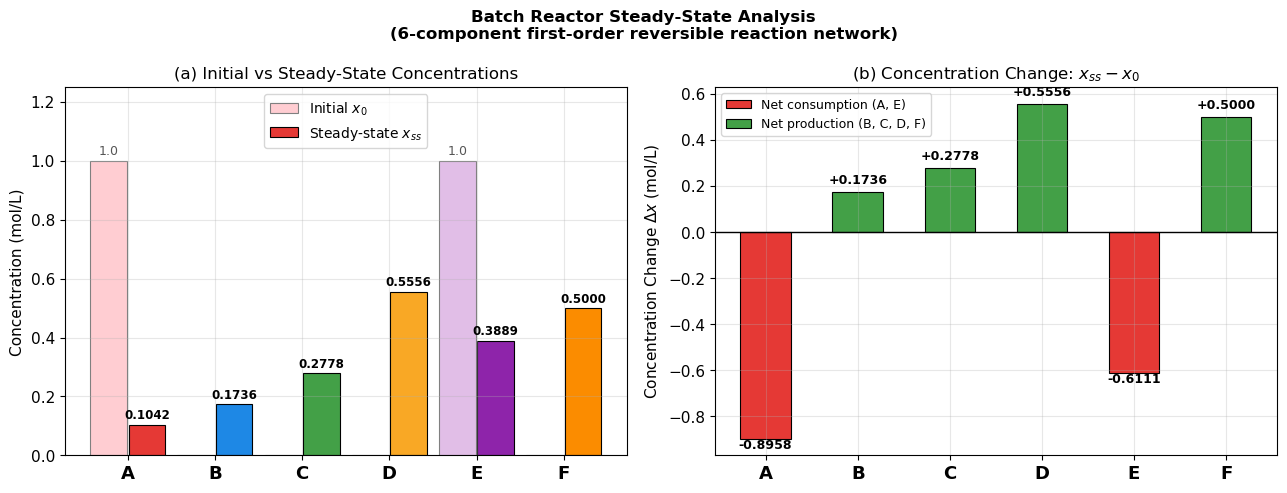


✓ 圖檔已儲存：d:\MyGit\ChemE-3502\Unit06\outputs\Unit06_Example_04\figs\batch_reactor_steady_state.png


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

colors_init = ['#FFCDD2', '#BBDEFB', '#C8E6C9', '#FFF9C4', '#E1BEE7', '#FFE0B2']
colors_ss   = ['#E53935', '#1E88E5', '#43A047', '#F9A825', '#8E24AA', '#FB8C00']
x_pos = np.arange(6)

# ─── 子圖1：初始濃度 vs 穩態濃度 ─────────────────────────────────
ax1 = axes[0]
ax1.bar(x_pos - 0.22, x0,   width=0.42, color=colors_init,
        edgecolor='gray',  linewidth=0.8, label='Initial $x_0$')
ax1.bar(x_pos + 0.22, x_ss, width=0.42, color=colors_ss,
        edgecolor='black', linewidth=0.8, label='Steady-state $x_{ss}$')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(names, fontsize=13, fontweight='bold')
ax1.set_ylabel('Concentration (mol/L)')
ax1.set_title('(a) Initial vs Steady-State Concentrations')
ax1.legend(fontsize=10)
ax1.set_ylim(0, 1.25)
for i, (xi0, xss) in enumerate(zip(x0, x_ss)):
    if xi0 > 0:
        ax1.text(i - 0.22, xi0 + 0.02, f'{xi0:.1f}',
                 ha='center', fontsize=9, color='#555555')
    ax1.text(i + 0.22, xss + 0.02, f'{xss:.4f}',
             ha='center', fontsize=8.5, fontweight='bold')

# ─── 子圖2：濃度變化量 Δx ─────────────────────────────────────────
ax2 = axes[1]
delta_x     = x_ss - x0
bar_colors  = ['#E53935' if d < 0 else '#43A047' for d in delta_x]
bars        = ax2.bar(x_pos, delta_x, width=0.55, color=bar_colors,
                      edgecolor='black', linewidth=0.8)
ax2.axhline(0, color='black', linewidth=1.0)
ax2.set_xticks(x_pos)
ax2.set_xticklabels(names, fontsize=13, fontweight='bold')
ax2.set_ylabel('Concentration Change $\\Delta x$ (mol/L)')
ax2.set_title('(b) Concentration Change: $x_{ss} - x_0$')
for bar, d in zip(bars, delta_x):
    offset = 0.025 if d >= 0 else -0.055
    ax2.text(bar.get_x() + bar.get_width()/2, d + offset,
             f'{d:+.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.legend(handles=[
    plt.Rectangle((0,0),1,1, fc='#E53935', ec='black', lw=0.8, label='Net consumption (A, E)'),
    plt.Rectangle((0,0),1,1, fc='#43A047', ec='black', lw=0.8, label='Net production (B, C, D, F)')],
    fontsize=9)

plt.suptitle('Batch Reactor Steady-State Analysis\n'
             '(6-component first-order reversible reaction network)',
             fontsize=12, fontweight='bold')
plt.tight_layout()

fig_path = FIG_DIR / 'batch_reactor_steady_state.png'
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
plt.show()
print(f"\n✓ 圖檔已儲存：{fig_path}")

---
### 6. 結論

| 項目 | 數值 |
|:----:|:----:|
| $x_A$ （穩態） | 0.1042 mol/L |
| $x_B$ （穩態） | 0.1736 mol/L |
| $x_C$ （穩態） | 0.2778 mol/L |
| $x_D$ （穩態） | 0.5556 mol/L |
| $x_E$ （穩態） | 0.3889 mol/L |
| $x_F$ （穩態） | 0.5000 mol/L |
| $\text{rank}(\mathbf{A}_{kin})$ | 5（奇異，無窮多解） |
| $\text{rank}(\mathbf{A})$ | 6（補充守恆後，唯一解） |
| $\det(\mathbf{A})$ | $-1.44 \times 10^{-3}$ |
| $\kappa(\mathbf{A})$ | 51.62（數值穩定） |
| 殘差 $\|\mathbf{Ax}-\mathbf{b}\|_2$ | $7.95 \times 10^{-17}$ |
| 動力學殘差 $\|\mathbf{A}_{kin}\mathbf{x}_{ss}\|_2$ | $8.42 \times 10^{-17}$ |

**核心學習要點**：
- 封閉批次系統的**總莫耳數守恆**造成動力學矩陣 $\mathbf{A}_{kin}$ 的列向量線性相依（所有行和為 0）
- 直接求解 $\mathbf{A}_{kin}\mathbf{x}=\mathbf{0}$ 有無窮多解；必須以**物理守恆律取代一條相依方程式**才能獲得唯一解
- 「以守恆約束補充奇異方程組」是化工問題中常見的策略，可推廣至管路網絡、混合槽組等系統